# 📊 Census Income Analysis & Prediction — End-to-End Project

This notebook is a **complete, ready-to-run** project for Google Colab. It covers:

1. **Data Preprocessing** — cleaning the raw census data
2. **Data Manipulation** — slicing, filtering, grouping and summarizing the data
3. **Exploratory Data Analysis (EDA)** — visualizing the important patterns
4. **Machine Learning** — Linear Regression, Logistic Regression, Decision Tree, and Random Forest

> **How to use this notebook:** Just run the cells from top to bottom (`Runtime ▸ Run all` in Colab). Each section has a short explanation before the code so you understand *what* is happening and *why*.

**Dataset:** `census-income.csv` — the classic "Adult / Census Income" dataset, which contains demographic details of individuals along with whether they earn `<=50K` or `>50K` per year.


#Problem Statement:
In this project, we need to preprocess the data and then develop an understanding
of different features of the data by performing exploratory analysis and creating
visualizations.Further, after having sufficient knowledge about the attributes we will perform
a predictive task of classification to predict whether an individual makes over 50K a year or
less,by using different Machine Learning Algorithms.


## 🔧 Step 0: Setup

First we import all the libraries we'll need for the whole project, and load the dataset.

- If you're running this in **Google Colab**, run the cell below — it will ask you to upload `census-income.csv` if it isn't already present.
- If the file is already in your Colab working directory (e.g. you mounted Drive or uploaded it earlier), it will be detected automatically and no upload prompt will appear.


In [1]:
# Install/upgrade packages (safe to run even if already installed)
!pip install -q pandas numpy matplotlib seaborn scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              confusion_matrix, accuracy_score, ConfusionMatrixDisplay)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)
print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [3]:
# Load the dataset — works whether you're in Colab or running locally
FILENAME = "census-income.csv"

if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        print("Please upload 'census-income.csv' when prompted...")
        uploaded = files.upload()
        FILENAME = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            "census-income.csv not found. Please place it in the working directory."
        )

census = pd.read_csv(FILENAME)
print("Shape of the dataset:", census.shape)
census.head()


Shape of the dataset: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**A quick look at the data:**
- `census.info()` tells us the data types of each column
- `census.describe()` gives summary statistics for the numeric columns


In [4]:
census.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
census.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 🧹 Step 1: Data Preprocessing

In this dataset, missing values are not stored as blank cells — they're recorded using a `?` symbol. This is common in real-world datasets.

**Task 1(a):** Replace all `?` entries with proper `NaN` (missing value) markers, so pandas actually recognizes them as missing.

**Task 1(b):** Remove every row that has any missing (`NaN`) value.


In [6]:
# (a) Replace '?' (and any surrounding whitespace variants) with NaN (i.e. "NA")
census.replace(to_replace=r'^\s*\?\s*$', value=np.nan, regex=True, inplace=True)

print("Missing values per column BEFORE removing rows:")
print(census.isnull().sum())


Missing values per column BEFORE removing rows:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
annual_income        0
dtype: int64


In [7]:
# (b) Remove all rows containing any NA values
print("Rows before removing NA:", census.shape[0])

census.dropna(axis=0, inplace=True)
census.reset_index(drop=True, inplace=True)

print("Rows after removing NA:", census.shape[0])
census.isnull().sum()   # should all be 0 now


Rows before removing NA: 32561
Rows after removing NA: 30162


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## 🔍 Step 2: Data Manipulation

Now that the data is clean, let's explore it using slicing, filtering, and aggregation — very similar to what you'd do in R with `dplyr`, but here we use `pandas`.

For reference, here are the columns in our cleaned dataset, in order:


In [8]:
print(list(census.columns))


['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'annual_income']


**(a)** Extract the `education` column and store it in `census_ed`.

In [9]:
census_ed = census['education']
census_ed.head()


,education
0,Bachelors
1,Bachelors
2,HS-grad
3,11th
4,Bachelors


**(b)** Extract all the columns from `age` to `relationship` (i.e. the first 8 columns) and store it in `census_seq`.

In [10]:
census_seq = census.loc[:, 'age':'relationship']
census_seq.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife


**(c)** Extract columns number **5, 8, 11** (using 1-based indexing, as in the original problem statement) and store it in `census_col`.

Column 5 → `education-num`, Column 8 → `relationship`, Column 11 → `capital-gain`.


In [11]:
# Convert 1-based column numbers to 0-based positions for pandas (.iloc)
census_col = census.iloc[:, [4, 7, 10]]
census_col.head()


,education-num,relationship,capital-gain
0,13,Not-in-family,2174
1,13,Husband,0
2,9,Not-in-family,0
3,7,Husband,0
4,13,Wife,0


**(d)** Extract all the **male** employees who work in **State-gov** and store it in `male_gov`.

In [12]:
male_gov = census[(census['sex'] == 'Male') & (census['workclass'] == 'State-gov')]
print("Number of male State-gov employees:", male_gov.shape[0])
male_gov.head()


Number of male State-gov employees: 795


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
11,30,State-gov,141297,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,40,India,>50K
32,22,State-gov,311512,Some-college,10,Married-civ-spouse,Other-service,Husband,Black,Male,0,0,15,United-States,<=50K
45,41,State-gov,101603,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
114,29,State-gov,267989,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,>50K


**(e)** Extract all the **39-year-olds** who either have a **Bachelor's degree** OR are **native of the United States**, and store the result in `census_us`.

In [13]:
census_us = census[
    (census['age'] == 39) &
    ((census['education'] == 'Bachelors') | (census['native-country'] == 'United-States'))
]
print("Number of matching rows:", census_us.shape[0])
census_us.head()


Number of matching rows: 742


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
26,39,Private,367260,HS-grad,9,Divorced,Exec-managerial,Not-in-family,White,Male,0,0,80,United-States,<=50K
119,39,Private,365739,Some-college,10,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
153,39,Federal-gov,235485,Assoc-acdm,12,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,42,United-States,<=50K
297,39,Self-emp-not-inc,174308,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K


**(f)** Extract **200 random rows** from the `census` DataFrame and store it in `census_200`.

We use `random_state=42` so the result is reproducible every time you run this notebook.


In [14]:
census_200 = census.sample(n=200, random_state=42)
census_200.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
217,28,Private,76714,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,55,United-States,>50K
24913,41,Private,178431,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,Taiwan,<=50K
17780,53,Private,290640,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,50,Germany,>50K
12484,31,Private,215297,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States,<=50K
8890,34,Local-gov,188682,Bachelors,13,Married-spouse-absent,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<=50K


**(g)** Get the count of different levels (categories) of the `workclass` column.

In [15]:
workclass_counts = census['workclass'].value_counts()
workclass_counts


,count
workclass,
Private,22286
Self-emp-not-inc,2499
Local-gov,2067
State-gov,1279
Self-emp-inc,1074
Federal-gov,943
Without-pay,14


**(h)** Calculate the **mean of `capital-gain`**, grouped by `workclass`.

In [16]:
capital_gain_by_workclass = census.groupby('workclass')['capital-gain'].mean().sort_values(ascending=False)
capital_gain_by_workclass


,capital-gain
workclass,
Self-emp-inc,4810.746741
Self-emp-not-inc,1913.134454
Private,879.858207
Federal-gov,832.321315
Local-gov,829.230285
State-gov,684.306489
Without-pay,487.857143


**(i)** Create separate DataFrames for **males** and **females** who earn **more than 50,000** annually.

In [17]:
male_above_50k = census[(census['sex'] == 'Male') & (census['annual_income'] == '>50K')]
female_above_50k = census[(census['sex'] == 'Female') & (census['annual_income'] == '>50K')]

print("Males earning >50K:", male_above_50k.shape[0])
print("Females earning >50K:", female_above_50k.shape[0])
male_above_50k.head()


Males earning >50K: 6396
Females earning >50K: 1112


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K
10,37,Private,280464,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,80,United-States,>50K
11,30,State-gov,141297,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,0,0,40,India,>50K
19,40,Private,193524,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,>50K


**(j)** Calculate the **percentage of people from the United States** who are **private employees** and **earn <= 50,000 annually**.

We express this as a percentage of the *entire (cleaned) dataset*.


In [18]:
us_private_le50k = census[
    (census['native-country'] == 'United-States') &
    (census['workclass'] == 'Private') &
    (census['annual_income'] == '<=50K')
]

percentage_us_private_le50k = (us_private_le50k.shape[0] / census.shape[0]) * 100
print(f"Percentage of people who are from the US, work in Private sector, and earn <=50K: {percentage_us_private_le50k:.2f}%")


Percentage of people who are from the US, work in Private sector, and earn <=50K: 51.70%


**(k)** Calculate the **percentage of married people** in the census data.

Any `marital-status` value that contains the word *"Married"* (e.g. `Married-civ-spouse`, `Married-AF-spouse`, `Married-spouse-absent`) is counted as married.


In [19]:
married_mask = census['marital-status'].str.contains('Married', case=False, na=False)
percentage_married = (married_mask.sum() / census.shape[0]) * 100
print(f"Percentage of married people: {percentage_married:.2f}%")


Percentage of married people: 80.17%


**(l)** Calculate the **percentage of high school graduates earning more than 50,000** annually.

We calculate this as a percentage of *all HS-grad individuals* (i.e., out of everyone whose highest education is `HS-grad`, what fraction earns >50K). We also show the percentage relative to the *whole dataset* for comparison.


In [20]:
hs_grads = census[census['education'] == 'HS-grad']
hs_grads_above_50k = hs_grads[hs_grads['annual_income'] == '>50K']

pct_of_hs_grads = (hs_grads_above_50k.shape[0] / hs_grads.shape[0]) * 100
pct_of_whole_dataset = (hs_grads_above_50k.shape[0] / census.shape[0]) * 100

print(f"% of HS-grads who earn >50K (out of all HS-grads): {pct_of_hs_grads:.2f}%")
print(f"% of HS-grads who earn >50K (out of the whole dataset): {pct_of_whole_dataset:.2f}%")


% of HS-grads who earn >50K (out of all HS-grads): 16.43%
% of HS-grads who earn >50K (out of the whole dataset): 5.36%


## 📈 Step 3: Exploratory Data Analysis (EDA) & Visualizations

Before building predictive models, let's *visualize* the data to understand patterns and relationships between features.


### 3.1 Distribution of Age

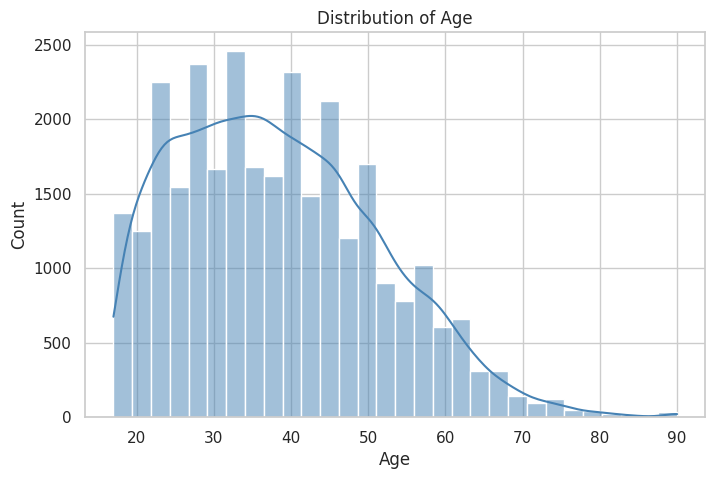

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(census['age'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


### 3.2 Income Class Distribution
How many people earn `<=50K` vs `>50K`?


/tmp/ipykernel_1095/3533937420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='annual_income', data=census, palette='Set2')


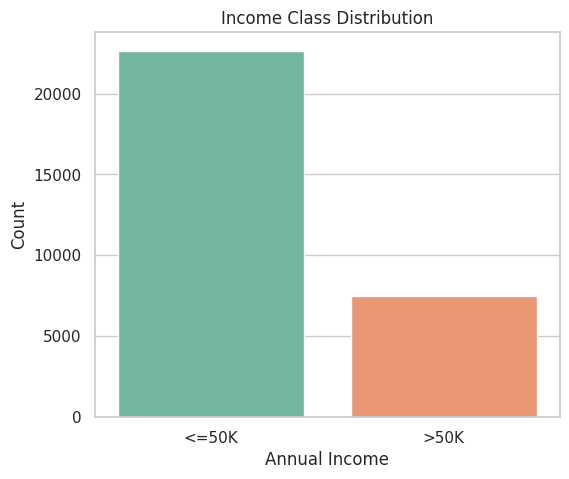

In [22]:
plt.figure(figsize=(6,5))
sns.countplot(x='annual_income', data=census, palette='Set2')
plt.title('Income Class Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Count')
plt.show()


### 3.3 Workclass Distribution

/tmp/ipykernel_1095/2877085201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='workclass', data=census, order=census['workclass'].value_counts().index, palette='viridis')


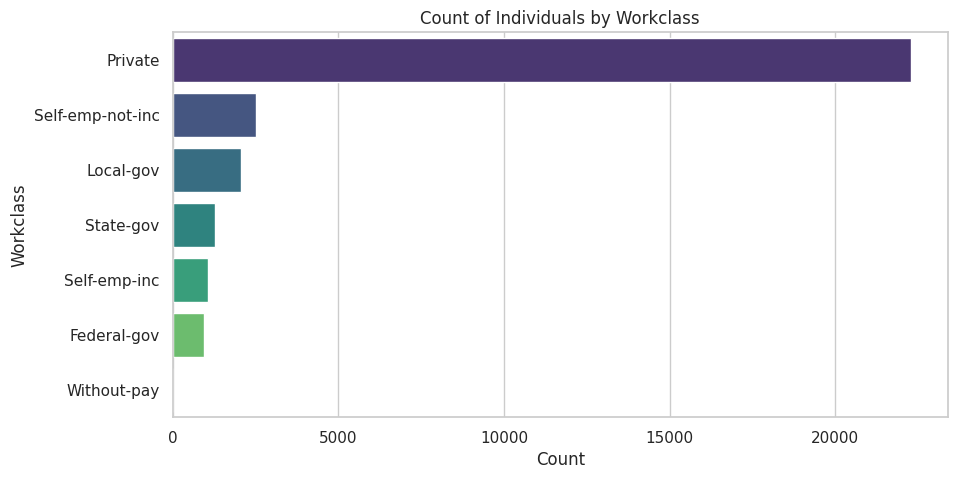

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(y='workclass', data=census, order=census['workclass'].value_counts().index, palette='viridis')
plt.title('Count of Individuals by Workclass')
plt.xlabel('Count')
plt.ylabel('Workclass')
plt.show()


### 3.4 Hours per Week vs Income
Do people who work more hours per week tend to earn more?


/tmp/ipykernel_1095/3126247691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='annual_income', y='hours-per-week', data=census, palette='Set3')


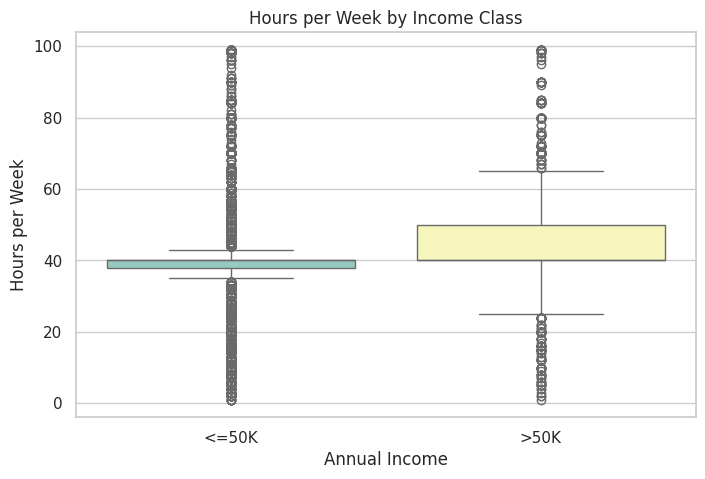

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='annual_income', y='hours-per-week', data=census, palette='Set3')
plt.title('Hours per Week by Income Class')
plt.xlabel('Annual Income')
plt.ylabel('Hours per Week')
plt.show()


### 3.5 Education vs Income
Which education levels are associated with higher income?


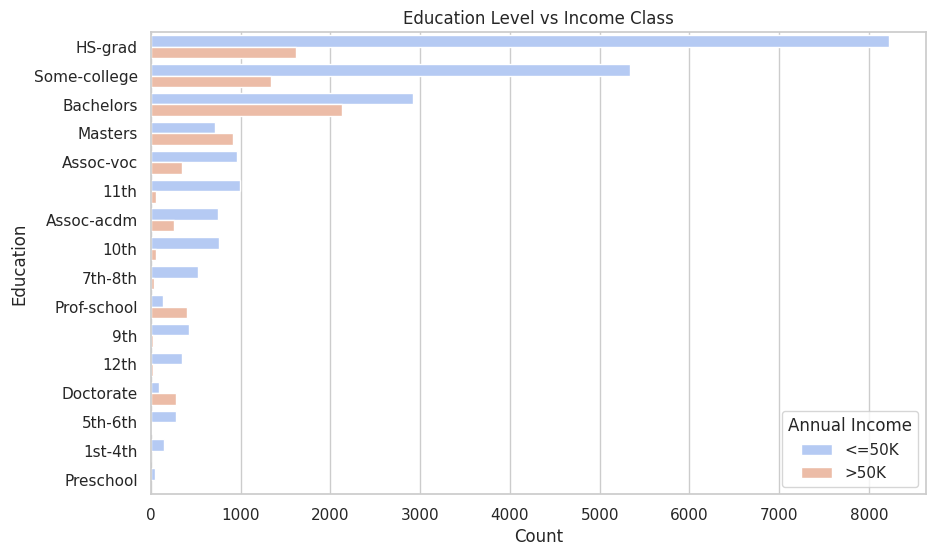

In [25]:
plt.figure(figsize=(10,6))
sns.countplot(y='education', hue='annual_income', data=census,
              order=census['education'].value_counts().index, palette='coolwarm')
plt.title('Education Level vs Income Class')
plt.xlabel('Count')
plt.ylabel('Education')
plt.legend(title='Annual Income')
plt.show()


### 3.6 Correlation Heatmap (Numeric Features)

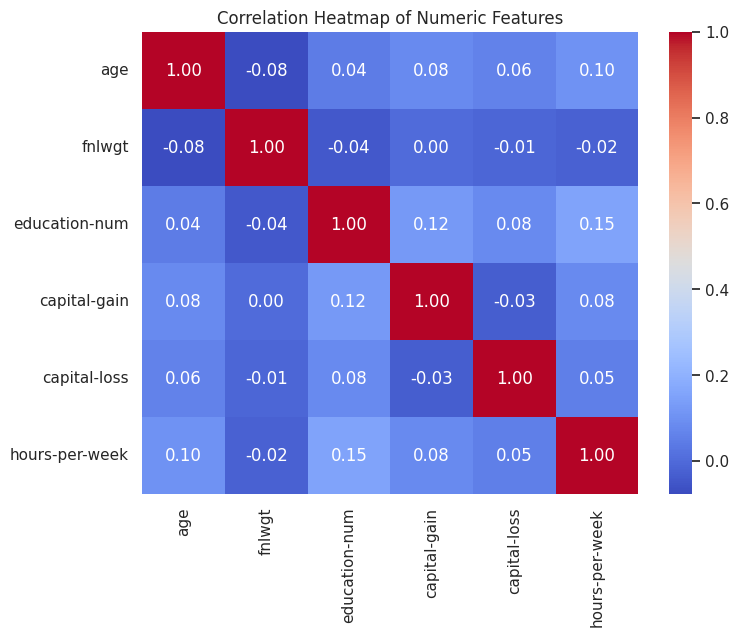

In [26]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
plt.figure(figsize=(8,6))
sns.heatmap(census[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


## 🛠️ Step 4: Preparing Data for Machine Learning

Our target column `annual_income` is a text label (`<=50K` / `>50K`). Most ML algorithms need numbers, so we'll encode it as **0** (`<=50K`) and **1** (`>50K`). We'll call this new numeric column **`X`** (as referenced in the problem statement).

We'll also prepare a couple of encoded versions of the dataset:
- **`census_dummies`** — categorical columns converted to dummy/one-hot variables (used for Logistic Regression)
- **`census_label_enc`** — categorical columns converted using Label Encoding (used for Decision Tree & Random Forest, which handle label-encoded categories well)


In [27]:
# Encode the target variable: 0 = <=50K, 1 = >50K
census['X'] = census['annual_income'].apply(lambda v: 1 if v.strip() == '>50K' else 0)
census[['annual_income', 'X']].head()


,annual_income,X
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


In [28]:
# Label-encoded version of the full dataset (for Decision Tree & Random Forest)
census_label_enc = census.copy()
categorical_cols = census_label_enc.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'annual_income']  # keep target separate

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    census_label_enc[col] = le.fit_transform(census_label_enc[col])
    label_encoders[col] = le

census_label_enc.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income,X
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,<=50K,0
1,50,4,83311,9,13,2,3,0,4,1,0,0,13,38,<=50K,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,<=50K,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,<=50K,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,<=50K,0


## 📐 Step 5: Linear Regression

**Goal:** Predict `hours-per-week` using `education-num` as the single predictor.

**Steps:**
1. Split data into **train (70%)** and **test (30%)** sets.
2. Fit a Linear Regression model on the **training set** (the standard, correct approach).
3. Use the model to **predict on the test set**, and evaluate the error.
4. Also predict on the **training set** itself (as the problem statement requests) to compare in-sample vs out-of-sample error.

> 📝 **Note:** The original problem statement says to "build a linear model on the test set" — this is very likely a wording slip, since the standard and statistically valid approach is to **train on the training set and evaluate on the test set**. We follow the standard, correct practice below, and additionally show predictions on the training set for completeness.


In [29]:
# 1. Train-test split (70:30)
X_lr = census[['education-num']]
y_lr = census['hours-per-week']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.30, random_state=42
)

print("Training set size:", X_train_lr.shape[0])
print("Test set size:", X_test_lr.shape[0])


Training set size: 21113
Test set size: 9049


In [30]:
# 2. Build the Linear Regression model on the TRAINING set
lin_reg = LinearRegression()
lin_reg.fit(X_train_lr, y_train_lr)

print(f"Intercept: {lin_reg.intercept_:.4f}")
print(f"Coefficient (education-num): {lin_reg.coef_[0]:.4f}")


Intercept: 34.0620
Coefficient (education-num): 0.6831


In [31]:
# 3. Predict on the TEST set and evaluate error
test_predictions = lin_reg.predict(X_test_lr)

mae_test = mean_absolute_error(y_test_lr, test_predictions)
mse_test = mean_squared_error(y_test_lr, test_predictions)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test_lr, test_predictions)

print("---- Performance on TEST set ----")
print(f"MAE  : {mae_test:.3f}")
print(f"MSE  : {mse_test:.3f}")
print(f"RMSE : {rmse_test:.3f}")
print(f"R^2  : {r2_test:.3f}")


---- Performance on TEST set ----
MAE  : 7.520
MSE  : 137.813
RMSE : 11.739
R^2  : 0.028


In [32]:
# 4. Predict on the TRAINING set and find the error (as literally requested in the problem statement)
train_predictions = lin_reg.predict(X_train_lr)

mae_train = mean_absolute_error(y_train_lr, train_predictions)
mse_train = mean_squared_error(y_train_lr, train_predictions)
rmse_train = np.sqrt(mse_train)

print("---- Performance on TRAINING set ----")
print(f"MAE  : {mae_train:.3f}")
print(f"MSE  : {mse_train:.3f}")
print(f"RMSE : {rmse_train:.3f}")


---- Performance on TRAINING set ----
MAE  : 7.513
MSE  : 141.203
RMSE : 11.883


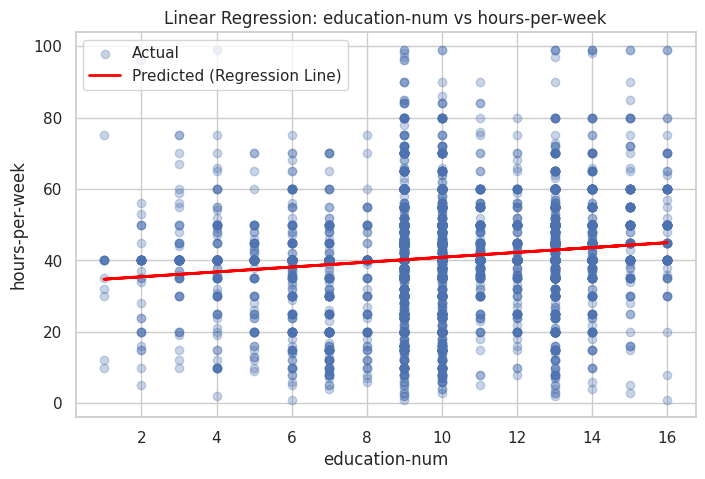

In [33]:
# Visualize actual vs predicted (test set)
plt.figure(figsize=(8,5))
plt.scatter(X_test_lr, y_test_lr, alpha=0.3, label='Actual')
plt.plot(X_test_lr, test_predictions, color='red', linewidth=2, label='Predicted (Regression Line)')
plt.xlabel('education-num')
plt.ylabel('hours-per-week')
plt.title('Linear Regression: education-num vs hours-per-week')
plt.legend()
plt.show()


## 🎯 Step 6: Logistic Regression — Simple Model

**Goal:** Predict yearly income class (`X`) using only `occupation` as the predictor.

**Steps:**
1. Convert `occupation` into dummy (one-hot) variables since it's categorical.
2. Split data into **train (65%)** and **test (35%)** sets.
3. Fit a Logistic Regression model.
4. Predict on the test set, build a **confusion matrix**, and calculate **accuracy**.


In [34]:
# 1. One-hot encode 'occupation'
occupation_dummies = pd.get_dummies(census['occupation'], prefix='occ', drop_first=True)

X_simple = occupation_dummies
y_simple = census['X']

# 2. Train-test split (65:35)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.35, random_state=42, stratify=y_simple
)

print("Training set size:", X_train_s.shape[0])
print("Test set size:", X_test_s.shape[0])


Training set size: 19605
Test set size: 10557


In [35]:
# 3. Build the logistic regression model
log_reg_simple = LogisticRegression(max_iter=1000)
log_reg_simple.fit(X_train_s, y_train_s)

# 4. Predict on the test set
y_pred_simple = log_reg_simple.predict(X_test_s)

# Confusion Matrix & Accuracy
cm_simple = confusion_matrix(y_test_s, y_pred_simple)
acc_simple = accuracy_score(y_test_s, y_pred_simple)

print("Confusion Matrix:")
print(cm_simple)
print(f"\nAccuracy: {acc_simple:.4f} ({acc_simple*100:.2f}%)")


Confusion Matrix:
[[7929    0]
 [2628    0]]

Accuracy: 0.7511 (75.11%)


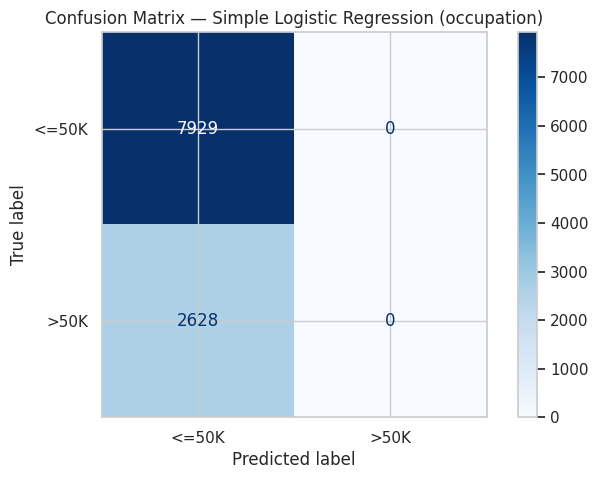

In [36]:
# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_simple, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Simple Logistic Regression (occupation)')
plt.show()


## 🎯 Step 7: Logistic Regression — Multiple Model

**Goal:** Predict yearly income class (`X`) using `age`, `workclass`, and `education` as predictors.

**Steps:**
1. Encode categorical predictors (`workclass`, `education`) using dummy variables; keep `age` numeric.
2. Split data into **train (80%)** and **test (20%)** sets.
3. Fit a Logistic Regression model.
4. Predict on the test set, build a **confusion matrix**, and calculate **accuracy**.


In [37]:
# 1. Prepare features
workclass_dummies = pd.get_dummies(census['workclass'], prefix='wc', drop_first=True)
education_dummies = pd.get_dummies(census['education'], prefix='edu', drop_first=True)

X_multi = pd.concat([census[['age']], workclass_dummies, education_dummies], axis=1)
y_multi = census['X']

# 2. Train-test split (80:20)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=42, stratify=y_multi
)

print("Training set size:", X_train_m.shape[0])
print("Test set size:", X_test_m.shape[0])


Training set size: 24129
Test set size: 6033


In [38]:
# 3. Build the multiple logistic regression model
log_reg_multi = LogisticRegression(max_iter=1000)
log_reg_multi.fit(X_train_m, y_train_m)

# 4. Predict on the test set
y_pred_multi = log_reg_multi.predict(X_test_m)

# Confusion Matrix & Accuracy
cm_multi = confusion_matrix(y_test_m, y_pred_multi)
acc_multi = accuracy_score(y_test_m, y_pred_multi)

print("Confusion Matrix:")
print(cm_multi)
print(f"\nAccuracy: {acc_multi:.4f} ({acc_multi*100:.2f}%)")


Confusion Matrix:
[[4279  252]
 [1045  457]]

Accuracy: 0.7850 (78.50%)


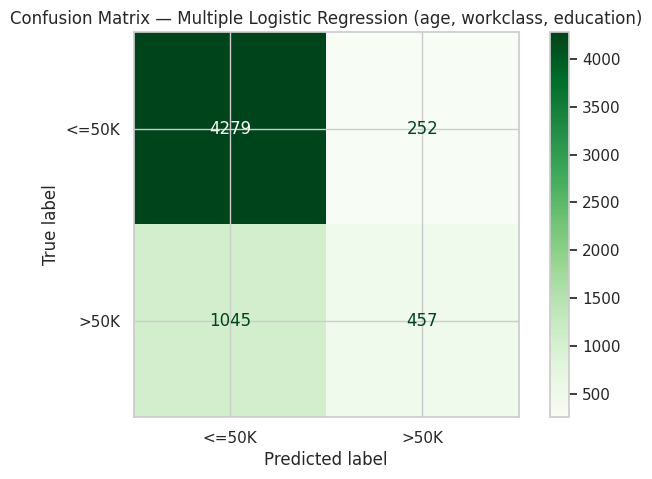

In [39]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix — Multiple Logistic Regression (age, workclass, education)')
plt.show()


## 🌳 Step 8: Decision Tree

**Goal:** Predict yearly income class (`X`) using **all other variables** as predictors.

**Steps:**
1. Use the label-encoded dataset (`census_label_enc`) so all categorical variables are numeric.
2. Split data into **train (70%)** and **test (30%)** sets.
3. Fit a Decision Tree Classifier.
4. Predict on the test set, build a **confusion matrix**, and calculate **accuracy**.


In [40]:
# 1. Features = everything except the original text target and our numeric target
feature_cols = [c for c in census_label_enc.columns if c not in ['annual_income', 'X']]

X_dt = census_label_enc[feature_cols]
y_dt = census_label_enc['X']

# 2. Train-test split (70:30)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y_dt, test_size=0.30, random_state=42, stratify=y_dt
)

print("Training set size:", X_train_dt.shape[0])
print("Test set size:", X_test_dt.shape[0])


Training set size: 21113
Test set size: 9049


In [41]:
# 3. Build the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

# 4. Predict on the test set
y_pred_dt = dt_model.predict(X_test_dt)

# Confusion Matrix & Accuracy
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)
acc_dt = accuracy_score(y_test_dt, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)
print(f"\nAccuracy: {acc_dt:.4f} ({acc_dt*100:.2f}%)")


Confusion Matrix:
[[5920  877]
 [ 834 1418]]

Accuracy: 0.8109 (81.09%)


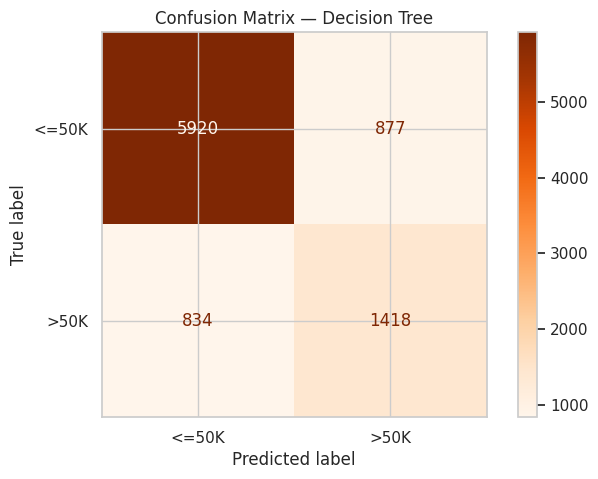

In [42]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix — Decision Tree')
plt.show()


/tmp/ipykernel_1095/2740886952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_dt.values, y=importance_dt.index, palette='mako')


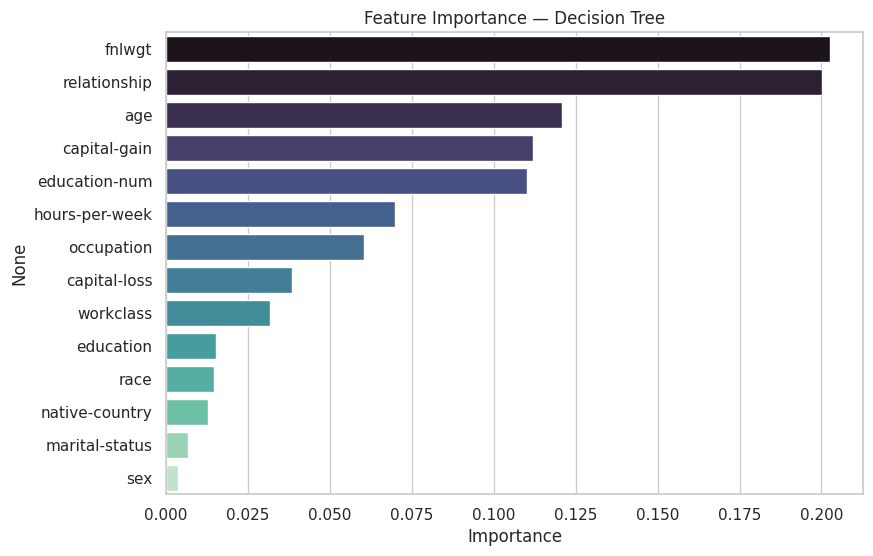

In [43]:
# Bonus: feature importance from the Decision Tree
importance_dt = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=importance_dt.values, y=importance_dt.index, palette='mako')
plt.title('Feature Importance — Decision Tree')
plt.xlabel('Importance')
plt.show()


## 🌲🌲 Step 9: Random Forest

**Goal:** Predict yearly income class (`X`) using **all other variables**, with **300 trees**.

**Steps:**
1. Reuse the same label-encoded features as the Decision Tree.
2. Split data into **train (80%)** and **test (20%)** sets.
3. Fit a Random Forest Classifier with `n_estimators=300`.
4. Predict on the test set, build a **confusion matrix**, and calculate **accuracy**.


In [44]:
# 2. Train-test split (80:20)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_dt, y_dt, test_size=0.20, random_state=42, stratify=y_dt
)

print("Training set size:", X_train_rf.shape[0])
print("Test set size:", X_test_rf.shape[0])


Training set size: 24129
Test set size: 6033


In [45]:
# 3. Build the Random Forest model with 300 trees
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)

# 4. Predict on the test set
y_pred_rf = rf_model.predict(X_test_rf)

# Confusion Matrix & Accuracy
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
acc_rf = accuracy_score(y_test_rf, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)
print(f"\nAccuracy: {acc_rf:.4f} ({acc_rf*100:.2f}%)")


Confusion Matrix:
[[4202  329]
 [ 551  951]]

Accuracy: 0.8541 (85.41%)


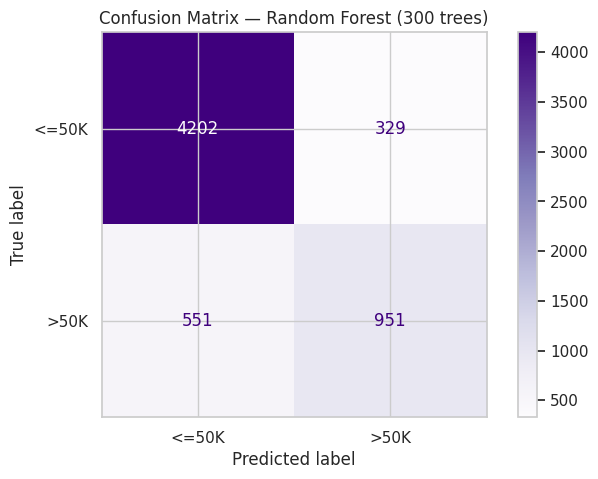

In [46]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Purples')
plt.title('Confusion Matrix — Random Forest (300 trees)')
plt.show()


/tmp/ipykernel_1095/1956341238.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_rf.values, y=importance_rf.index, palette='rocket')


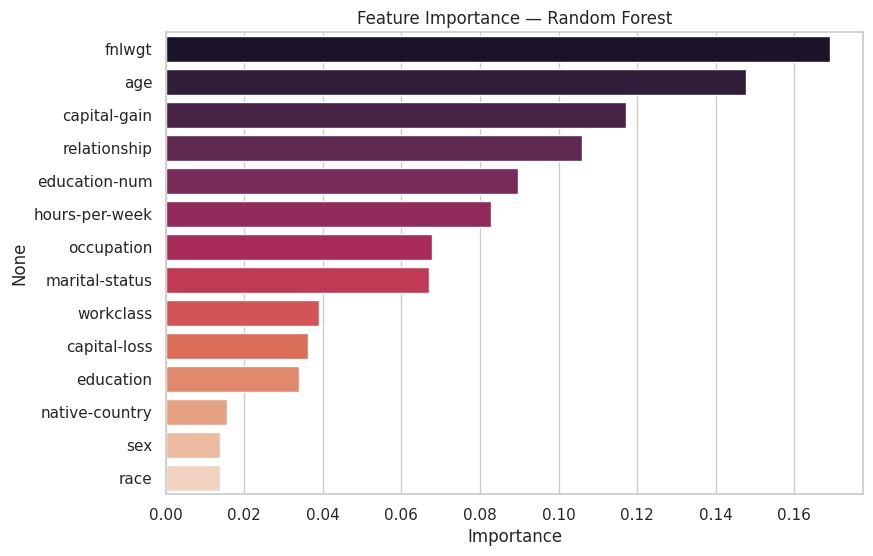

In [47]:
# Bonus: feature importance from the Random Forest
importance_rf = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=importance_rf.values, y=importance_rf.index, palette='rocket')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.show()


## ✅ Step 10: Model Comparison & Summary

Let's put all the classification model accuracies side by side to see which performed best.


In [48]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (occupation only)',
        'Logistic Regression (age, workclass, education)',
        'Decision Tree (all features)',
        'Random Forest (all features, 300 trees)'
    ],
    'Accuracy': [acc_simple, acc_multi, acc_dt, acc_rf]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
results


,Model,Accuracy,Accuracy (%)
0,"Random Forest (all features, 300 trees)",0.854136,85.41
1,Decision Tree (all features),0.810918,81.09
2,"Logistic Regression (age, workclass, education)",0.785016,78.50
3,Logistic Regression (occupation only),0.751066,75.11


/tmp/ipykernel_1095/598198467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy (%)', y='Model', data=results, palette='crest')


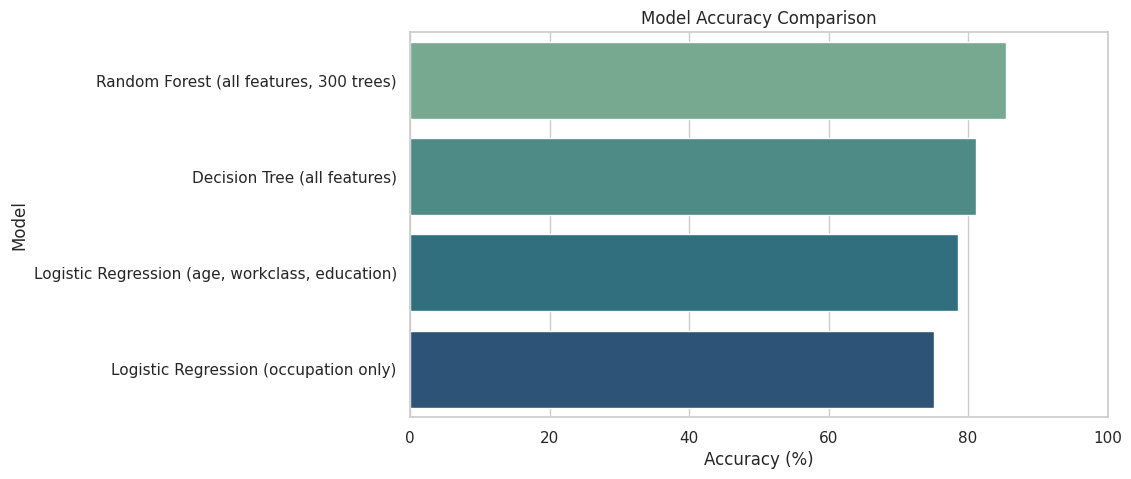

In [49]:
plt.figure(figsize=(9,5))
sns.barplot(x='Accuracy (%)', y='Model', data=results, palette='crest')
plt.title('Model Accuracy Comparison')
plt.xlim(0, 100)
plt.show()


### 🏁 Conclusion

- We cleaned the census dataset by treating `?` entries as missing values and dropping incomplete rows.
- We explored the data through slicing, filtering, grouping, and several visualizations (age distribution, income split, education vs income, correlation heatmap, etc.).
- We built four classification models to predict whether a person earns more than \$50K a year, and compared their accuracies above.
- Typically, **ensemble methods like Random Forest** outperform a single Decision Tree or simple Logistic Regression, because they combine many trees to reduce overfitting and variance — but check the results table above for what this specific run produced.

**Next steps you could try:**
- Tune hyperparameters (e.g. `max_depth`, `min_samples_leaf` for trees; `C` for Logistic Regression) using `GridSearchCV`.
- Try Gradient Boosting (`GradientBoostingClassifier` or `XGBoost`) for potentially higher accuracy.
- Handle class imbalance (there are more `<=50K` earners than `>50K`) using techniques like class weighting or SMOTE.
